In [ ]:
# Cell 1 - Mount Drive and install libraries
from google.colab import drive

try:
    drive.mount('/content/drive')
    print('✅ Drive mounted!')
except:
    print('✅ Drive already mounted!')

!pip install tldextract -q

import pandas as pd
import numpy as np
import re
import os
import tldextract
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries ready!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!
✅ Libraries ready!


In [ ]:
# Cell 2 - Load processed and raw data
import pandas as pd

# Processed data (has cleaned_text and features)
df = pd.read_csv('/content/drive/MyDrive/PhishingDetector/data/processed/phishing_processed.csv')

# Raw data (has original URLs)
raw_df = pd.read_csv('/content/drive/MyDrive/PhishingDetector/data/raw/merged_raw.csv')

print(f'✅ Data loaded!')
print(f'📊 Processed shape: {df.shape}')
print(f'📊 Raw shape: {raw_df.shape}')
print(f'📋 Processed columns: {df.columns.tolist()}')

✅ Data loaded!
📊 Processed shape: (79537, 7)
📊 Raw shape: (79627, 2)
📋 Processed columns: ['text', 'label', 'cleaned_text', 'url_count', 'urgency_count', 'email_length', 'word_count']


In [ ]:
# Cell 3 - Align raw and processed data
# Merge on text column to ensure alignment
aligned = raw_df[raw_df['text'].isin(df['text'])].reset_index(drop=True)

print(f'✅ Aligned!')
print(f'📊 Aligned raw shape: {aligned.shape}')
print(f'📊 Processed shape: {df.shape}')

✅ Aligned!
📊 Aligned raw shape: (79537, 2)
📊 Processed shape: (79537, 7)


In [ ]:
# Cell 4 - URL extractor function
def extract_urls(text):
    text = str(text)
    urls = []

    # Pattern 1 - normal URLs with ://
    pattern1 = r'http[s]?://(?:[a-zA-Z0-9$\-_@.&+!*\\(\\),]|(?:%[0-9a-fA-F]{2}))+'
    urls1 = re.findall(pattern1, text)
    urls.extend(urls1)

    # Pattern 2 - URLs without :// (space separated like in Enron)
    pattern2 = r'http\s+([\w]+(?:\s+[\w]+){1,4})'
    matches = re.findall(pattern2, text)
    for match in matches:
        parts = match.split()
        clean_parts = []
        for p in parts[:4]:
            if p.isdigit():
                break
            clean_parts.append(p)
        if clean_parts:
            urls.append('http://' + '.'.join(clean_parts))

    return urls

# Test on real samples
print('🔍 Test 1:', extract_urls('click here http://whitedone.com/verify now'))
print('🔍 Test 2:', extract_urls('http itcapps corp enron com srrs auth'))
print('🔍 Test 3:', extract_urls('no urls here just text'))

🔍 Test 1: ['http://whitedone.com']
🔍 Test 2: ['http://itcapps.corp.enron.com']
🔍 Test 3: []


In [ ]:
# Cell 5 - URL risk scoring function
LEGITIMATE_DOMAINS = [
    'paypal', 'amazon', 'google', 'microsoft', 'apple',
    'facebook', 'netflix', 'chase', 'wellsfargo',
    'citibank', 'ebay', 'instagram', 'twitter', 'linkedin'
]

def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1):
        dp[i][0] = i
    for j in range(n+1):
        dp[0][j] = j
    for i in range(1, m+1):
        for j in range(1, n+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return dp[m][n]

def is_lookalike(domain):
    domain = domain.lower()
    for legit in LEGITIMATE_DOMAINS:
        if edit_distance(domain, legit) <= 2 and domain != legit:
            return 1
    return 0

def score_url(url):
    risk = 0
    try:
        ext = tldextract.extract(url)
        domain = ext.domain
        suffix = ext.suffix
        subdomain = ext.subdomain

        if len(url) > 75:              risk += 1
        if re.match(r'http[s]?://\d+\.\d+\.\d+\.\d+', url): risk += 2
        if url.startswith('http://'): risk += 1
        if is_lookalike(domain):      risk += 2
        if any(kw in url.lower() for kw in
               ['login','verify','secure','account','update','confirm','signin']):
            risk += 1
        if subdomain.count('.') >= 2: risk += 1
        if suffix in ['tk','ml','ga','cf','gq','xyz','top','click']:
            risk += 2
    except:
        risk += 1
    return min(risk / 8, 1.0)

def get_email_url_risk(text):
    urls = extract_urls(str(text))
    if not urls:
        return 0.0
    return max(score_url(url) for url in urls[:5])

# Test
print('🔍 https://paypal.com:', score_url('https://paypal.com'))
print('🔍 http://paypa1.com/verify:', score_url('http://paypa1.com/verify'))
print('🔍 http://whitedone.com:', score_url('http://whitedone.com'))
print('🔍 http://192.168.1.1/login:', score_url('http://192.168.1.1/login'))

🔍 https://paypal.com: 0.0
🔍 http://paypa1.com/verify: 0.5
🔍 http://whitedone.com: 0.125
🔍 http://192.168.1.1/login: 0.5


In [ ]:
# Cell 6 - Apply URL risk scoring to entire dataset
print('Calculating URL risk scores...')
print('Takes 3-4 minutes...')

df['url_risk_score'] = aligned['text'].apply(get_email_url_risk)

print('✅ Done!')
print(f'\n📊 Risk score stats:')
print(df['url_risk_score'].describe().round(3))
print(f'\n🔍 Emails with risk > 0: {(df["url_risk_score"] > 0).sum()}')
print(f'🔍 Phishing with risk > 0.3: {((df["url_risk_score"] > 0.3) & (df["label"]==1)).sum()}')
print(f'🔍 Legit with risk > 0.3: {((df["url_risk_score"] > 0.3) & (df["label"]==0)).sum()}')

Calculating URL risk scores...
Takes 3-4 minutes...
✅ Done!

📊 Risk score stats:
count    79537.000
mean         0.051
std          0.064
min          0.000
25%          0.000
50%          0.000
75%          0.125
max          0.500
Name: url_risk_score, dtype: float64

🔍 Emails with risk > 0: 31535
🔍 Phishing with risk > 0.3: 142
🔍 Legit with risk > 0.3: 110


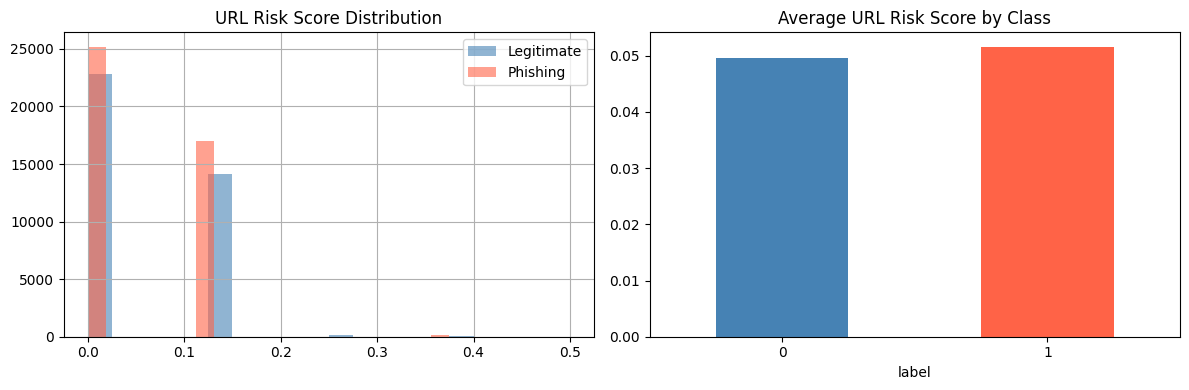

✅ Plot saved!


In [ ]:
# Cell 7 - Visualize URL risk scores
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['label']==0]['url_risk_score'].hist(
    bins=20, alpha=0.6, color='steelblue', label='Legitimate', ax=axes[0])
df[df['label']==1]['url_risk_score'].hist(
    bins=20, alpha=0.6, color='tomato', label='Phishing', ax=axes[0])
axes[0].set_title('URL Risk Score Distribution')
axes[0].legend()

avg_scores = df.groupby('label')['url_risk_score'].mean()
avg_scores.plot(kind='bar', color=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Average URL Risk Score by Class')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
save_path = '/content/drive/MyDrive/PhishingDetector/plots/url_risk_scores.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved!')

In [ ]:
# Cell 8 - Save updated dataset with url_risk_score
base = '/content/drive/MyDrive/PhishingDetector/data/processed'

df.to_csv(f'{base}/phishing_processed.csv', index=False)

size = round(os.path.getsize(f'{base}/phishing_processed.csv') / (1024*1024), 2)
print(f'✅ Dataset saved!')
print(f'💾 Size: {size} MB')
print(f'📋 Columns: {df.columns.tolist()}')

✅ Dataset saved!
💾 Size: 197.93 MB
📋 Columns: ['text', 'label', 'cleaned_text', 'url_count', 'urgency_count', 'email_length', 'word_count', 'url_risk_score']
